In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importing libraries

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [ ]:
# Load SCAN-B cancer (9,206 samples) and normal (66 samples) gene expression datasets

cancer_data = pd.read_csv(
    "/content/drive/MyDrive/MSc Project code/SCANB.9206.genematrix_noNeg.txt",
    sep='\t',
    index_col=0,
    header=0,
    na_values='null'
)

# Load normal data
normal_data = pd.read_csv(
    "/content/drive/MyDrive/MSc Project code/Normal.66.genematrix_noNeg.txt",
    sep='\t',
    index_col=0,
    header=0
)

In [ ]:
# Display dataset shapes and summary statistics

print("Cancer data shape:", cancer_data.shape)
print("Normal data shape:", normal_data.shape)

# Summary statistics
print("\nCancer data stats:")
display(cancer_data.describe())

print("\nNormal data stats:")
display(normal_data.describe())

Cancer data shape: (19675, 9206)
Normal data shape: (19675, 66)

Cancer data stats:


,S000001.l.r.m.c.lib.g.k2.a.t,S000002.l.r.m.c.lib.g2.k2.a.t,S000002.l.r.m.c.lib.g.k2.a.t,S000003.l.r.m2.c.lib.g.k2.a.t,S000003.l.r.m.c.lib.g.k2.a.t,S000004.l.r.m2.c.lib.g.k2.a.t,S000004.l.r.m.c.lib.g.k2.a.t,S000005.l.r.m.c.lib.g.k2.a.t,S000006.l.r.lib.g.k2.a.t,S000006.l.r.m2.c.lib.g.k2.a.t,...,S012954.l.r.n.m.c.lib.g.k2.a.t,S012956.l.r.n.m.c.lib.g.k2.a.t,S012961.l.r.n.m.c.lib.g.k2.a.t,S012962.l.r.n.m.c.lib.g.k2.a.t,S012964.l.r.n.m.c.lib.g.k2.a.t,S012966.l.r.n.m.c.lib.g.k2.a.t,S012967.l.r.n.m.c.lib.g.k2.a.t,S012968.l.r.n.m.c.lib.g.k2.a.t,S012969.l.r.n.m.c.lib.g.k2.a.t,S012973.l.r.n.m.c.lib.g.k2.a.t
count,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,...,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000
mean,21.260244,21.458707,21.029552,21.194287,20.772179,21.803744,21.265774,22.224230,24.742601,25.224171,...,19.565983,22.064084,22.143965,26.453205,22.651114,21.661184,21.943569,18.972981,20.836909,20.778180
std,156.267609,147.428210,144.117303,237.117846,224.299231,227.807949,193.366602,176.369424,292.161942,269.808857,...,144.346305,211.233764,221.588674,418.444633,207.583654,143.661849,145.569408,121.607490,212.092636,258.617281
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.070715,0.083612,0.095539,0.143814,0.130371,0.094302,0.140309,0.100456,0.103880,0.130594,...,0.107217,0.134404,0.060865,0.087146,0.100895,0.038732,0.049698,0.086994,0.117657,0.021643
50%,3.164206,3.586512,3.575798,3.590126,3.620674,2.953851,3.659062,3.773793,3.192174,3.293908,...,3.144258,3.316033,2.851034,3.165001,3.078332,2.509868,2.591719,3.207492,2.896586,2.073567
75%,12.381199,14.363302,13.910305,12.323739,12.432988,12.350295,13.381598,13.313396,11.649560,12.140543,...,12.912493,11.810810,11.313004,11.662033,12.849509,12.716755,12.751315,13.286414,11.932619,12.197321
max,9042.150392,10301.148276,9609.868840,23589.918997,21908.760369,15456.351562,12978.906729,9437.608137,15800.576562,15377.277344,...,7762.708984,13282.666016,13049.764648,29452.833984,14291.293945,8667.295898,7320.551270,7389.654297,12141.990234,15549.890625



Normal data stats:


,NORM66.001,NORM66.002,NORM66.003,NORM66.004,NORM66.005,NORM66.006,NORM66.007,NORM66.008,NORM66.009,NORM66.010,...,NORM66.057,NORM66.058,NORM66.059,NORM66.060,NORM66.061,NORM66.062,NORM66.063,NORM66.064,NORM66.065,NORM66.066
count,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,...,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000,19675.000000
mean,21.537030,22.888101,22.457992,21.701464,21.706400,19.636479,19.797727,21.427370,19.232031,21.563427,...,23.079116,21.145760,21.297993,21.158053,21.404046,23.044102,20.859191,22.236152,23.503630,23.433769
std,208.185727,178.495371,213.201903,184.319750,207.352842,173.849921,146.348036,265.062256,115.516594,184.277813,...,277.836803,177.302003,186.597691,201.534203,176.117785,258.768657,168.656279,212.816625,271.180326,211.347255
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.166758,0.225400,0.224821,0.168654,0.120436,0.118450,0.139308,0.083198,0.221863,0.219151,...,0.107843,0.167415,0.153518,0.056914,0.112334,0.147225,0.197960,0.145063,0.116544,0.184027
50%,3.735847,4.060727,4.245387,3.834677,3.007105,2.771906,3.316718,2.384210,4.099008,3.802857,...,2.827287,3.722443,3.145905,3.046088,3.363905,3.400581,3.817267,3.598504,2.896307,3.928499
75%,12.287825,13.031865,13.274244,13.138294,11.938356,12.296353,12.877231,11.421557,14.256732,13.200545,...,11.714225,13.170720,12.432339,11.596888,11.880952,12.379011,13.185061,13.099549,11.839450,12.925593
max,10433.499023,9270.134766,12745.676758,10286.278320,10571.303711,8869.479492,7437.651367,14326.447266,5912.981934,10142.565430,...,14743.878906,10558.029297,9636.938477,10399.061523,9812.788086,15775.669922,8750.576172,12165.007812,15203.991211,10818.647461


In [ ]:
# Rename CANCER samples
cancer_data.columns = [f"Cancer_{i}" for i in range(1, cancer_data.shape[1] + 1)]

# Rename NORMAL samples
normal_data.columns = [f"Normal_{i}" for i in range(1, normal_data.shape[1] + 1)]


print("Cancer samples :", cancer_data.columns[:5])
print("Normal samples :", normal_data.columns[:5])

Cancer samples : Index(['Cancer_1', 'Cancer_2', 'Cancer_3', 'Cancer_4', 'Cancer_5'], dtype='object')
Normal samples : Index(['Normal_1', 'Normal_2', 'Normal_3', 'Normal_4', 'Normal_5'], dtype='object')


In [ ]:
cancer_data.head()

,Cancer_1,Cancer_2,Cancer_3,Cancer_4,Cancer_5,Cancer_6,Cancer_7,Cancer_8,Cancer_9,Cancer_10,...,Cancer_9197,Cancer_9198,Cancer_9199,Cancer_9200,Cancer_9201,Cancer_9202,Cancer_9203,Cancer_9204,Cancer_9205,Cancer_9206
ENSG00000000003.14,39.809402,14.636051,9.252979,40.313057,47.864565,26.838545,24.150045,42.819592,50.060670,41.503738,...,20.185877,17.747004,11.265353,41.884953,46.268154,57.656853,14.181947,12.740876,43.746647,1.216635
ENSG00000000005.5,0.056676,0.731341,0.234664,0.056676,0.273483,0.000000,0.212344,0.355951,0.154629,0.000000,...,0.987634,0.185795,0.000000,0.093239,0.000000,0.000000,0.133005,0.138664,5.705500,0.000000
ENSG00000000419.12,39.898607,59.511723,50.317306,22.715398,25.833073,44.654636,47.588663,26.202699,23.448225,23.345047,...,37.520241,28.135132,27.591070,28.375940,40.584061,62.569298,81.797920,50.968998,28.439642,30.358147
ENSG00000000457.13,2.795663,1.877334,2.036975,17.746697,19.286112,7.989046,5.351055,5.635212,2.830489,2.373862,...,13.297224,8.466818,8.513699,12.007030,13.600958,14.147722,9.286246,5.475942,7.158357,9.201006
ENSG00000000460.16,2.057978,5.700723,4.841146,6.732664,6.958458,6.010187,6.006703,1.079753,2.328360,3.312300,...,4.494801,3.698159,3.970099,2.405475,30.584806,33.102444,15.867513,5.709969,3.495119,5.637100


In [ ]:
normal_data.head()

,Normal_1,Normal_2,Normal_3,Normal_4,Normal_5,Normal_6,Normal_7,Normal_8,Normal_9,Normal_10,...,Normal_57,Normal_58,Normal_59,Normal_60,Normal_61,Normal_62,Normal_63,Normal_64,Normal_65,Normal_66
ENSG00000000003.14,33.626572,42.076679,30.682674,30.760889,50.458496,46.753681,77.328636,46.072418,50.081264,44.572056,...,51.442371,52.242290,57.667683,36.839851,27.860605,39.383877,46.034096,46.472797,41.383579,32.108913
ENSG00000000005.5,12.970957,6.086121,23.076481,3.884471,21.829283,7.425698,6.953922,23.151409,0.973608,6.261407,...,20.446266,15.325600,4.752749,29.333321,23.919920,19.889914,5.040112,12.739979,25.206795,6.700304
ENSG00000000419.12,27.643644,40.698814,33.133678,35.684563,42.145130,40.177418,44.482719,39.361763,40.188293,42.928257,...,42.266571,47.083076,40.431629,34.824539,29.687693,32.973839,39.698410,39.854141,44.069736,30.844980
ENSG00000000457.13,3.636509,5.308075,5.502258,8.607203,6.403152,6.915540,9.526284,6.444725,10.219261,7.310094,...,6.165828,7.810611,9.517643,3.373771,4.863076,7.108354,8.052911,8.393535,9.511464,10.834065
ENSG00000000460.16,1.675113,2.465603,2.237807,2.710130,2.721855,4.004060,3.754046,3.431169,3.922761,3.002821,...,3.347709,3.812011,3.530172,0.997122,1.762603,2.730401,2.789891,4.849131,1.976235,3.935998


In [ ]:
  # Check values
  print("Max value in cancer_data:", cancer_data.max().max())
  print("Min value in cancer_data:", cancer_data.min().min())

Max value in cancer_data: 163377.090663767
Min value in cancer_data: 0.0


In [ ]:
# --- Data Preparation ---
# Split
temp_data = cancer_data.T
train_data, test_data = train_test_split(temp_data, train_size=8000, random_state=42)

train_data = train_data.T
test_data = test_data.T

# Precompute all possible normal indices
n_normal = normal_data.shape[1]
n_train = train_data.shape[1]
all_normal_indices = np.tile(np.arange(n_normal), int(np.ceil(n_train / n_normal)))[:n_train]

# Precompute log-transformed pure cancer targets (just for training)
y_train_pure = torch.FloatTensor(np.log2(train_data + 0.1).T.values)

In [ ]:
# DAE Model
class DAE(nn.Module):
    def __init__(self, input_dim=19675):
        super(DAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.1)
        )
        self.bottleneck = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.1),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.1),
            nn.Linear(1024, input_dim)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        return self.decoder(x)

In [ ]:
#Training the denoising autoencoder (DAE) to reconstruct clean cancer profiles from mixed inputs.

def train_model(X_train, y_train, X_val, y_val, batch_size=200, epochs=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Prepare training and validation data loaders
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Define model, loss function and optimiser
    model = DAE().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-6)

    # Track best model and validation loss (for early stopping)
    best_val_loss = float('inf')
    best_model = None

    for epoch in range(epochs):
        # Training loop
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()
        val_loss /= len(val_loader)

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = model.state_dict()

        if epoch > 20 and val_loss > 1.5 * best_val_loss:
            break

    # Load best model
    model.load_state_dict(best_model)
    return model, train_loss, val_loss


In [ ]:
# Validation function
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            total_loss += criterion(outputs, batch_y).item()
    return total_loss / len(loader)

In [ ]:
# Evaluation function - Comparing noisy input vs. DAE output against clean targets
def evaluate(model, X_val, y_val):
    device = next(model.parameters()).device
    with torch.no_grad():       # Disable gradient calculation for evaluation
        Xv = X_val.to(device)
        yv = y_val.to(device)
        yhat = model(Xv)       # Generate reconstructed outputs from the model

        # Convert tensors to NumPy arrays for metric calculations
        yv_np = yv.cpu().numpy().reshape(-1)
        Xv_np = Xv.cpu().numpy().reshape(-1)
        yhat_np = yhat.cpu().numpy().reshape(-1)

        # Return reconstruction metrics (before vs. after DAE)
        return {
            'mse_noisy': mean_squared_error(yv_np, Xv_np),
            'r2_noisy': r2_score(yv_np, Xv_np),
            'mse_dae': mean_squared_error(yv_np, yhat_np),
            'r2_dae': r2_score(yv_np, yhat_np)
        }

In [ ]:
# Creating folder to save trained models and results
import os
os.makedirs('saved_models', exist_ok=True)

results = []

# Define cancer-to-normal ratios to test
ratios_to_test = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0]

for cancer_ratio in ratios_to_test:
    normal_ratio = 1.0 - cancer_ratio
    print(f"\n=== Testing {cancer_ratio:.0%} cancer / {normal_ratio:.0%} normal ===")

    # Create mixed data
    if cancer_ratio == 0:
        mixed_values = normal_data.iloc[:, all_normal_indices].values
    elif normal_ratio == 0:
        mixed_values = train_data.values
    else:
        mixed_values = (cancer_ratio * train_data.values +
                       normal_ratio * normal_data.iloc[:, all_normal_indices].values)

    # Applying Log transform
    mixed_train_log = torch.FloatTensor(np.log2(pd.DataFrame(
        mixed_values, index=train_data.index) + 0.1).T.values)

    # Split into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        mixed_train_log, y_train_pure, test_size=0.1, random_state=42)

    # Train and evaluate
    model, train_loss, val_loss = train_model(X_train, y_train, X_val, y_val)
    eval_results = evaluate(model, X_val, y_val)

    # Saving the model weights
    model_filename = f'saved_models/model_ratio_{cancer_ratio:.1f}.pth'
    torch.save(model.state_dict(), model_filename)
    print(f"Model saved: {model_filename}")

    # Saving the entire model
    full_model_filename = f'saved_models/full_model_ratio_{cancer_ratio:.1f}.pth'
    torch.save(model, full_model_filename)

    # Store results
    results.append({
        'cancer_ratio': cancer_ratio,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'model_path': model_filename,  # Store path for later reference
        **eval_results,
        'mse_improvement': eval_results['mse_noisy'] - eval_results['mse_dae']
    })

    # Immediate output
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"MSE Improvement: {results[-1]['mse_improvement']:.4f}")

    # Saving all results for later analysis
results_df = pd.DataFrame(results)
results_df.to_csv('saved_models/training_results.csv', index=False)
print("\nAll models and results saved successfully!")


=== Testing 100% cancer / 0% normal ===
Model saved: saved_models/model_ratio_1.0.pth
Train Loss: 0.2915 | Val Loss: 0.3401
MSE Improvement: -0.3401

=== Testing 90% cancer / 10% normal ===
Model saved: saved_models/model_ratio_0.9.pth
Train Loss: 0.2918 | Val Loss: 0.3488
MSE Improvement: -0.2464

=== Testing 80% cancer / 20% normal ===
Model saved: saved_models/model_ratio_0.8.pth
Train Loss: 0.2904 | Val Loss: 0.3444
MSE Improvement: -0.1238

=== Testing 70% cancer / 30% normal ===
Model saved: saved_models/model_ratio_0.7.pth
Train Loss: 0.2911 | Val Loss: 0.3505
MSE Improvement: -0.0060

=== Testing 60% cancer / 40% normal ===
Model saved: saved_models/model_ratio_0.6.pth
Train Loss: 0.2928 | Val Loss: 0.3723
MSE Improvement: 0.1029

=== Testing 50% cancer / 50% normal ===
Model saved: saved_models/model_ratio_0.5.pth
Train Loss: 0.2955 | Val Loss: 0.3638
MSE Improvement: 0.2521

=== Testing 40% cancer / 60% normal ===
Model saved: saved_models/model_ratio_0.4.pth
Train Loss: 0.3

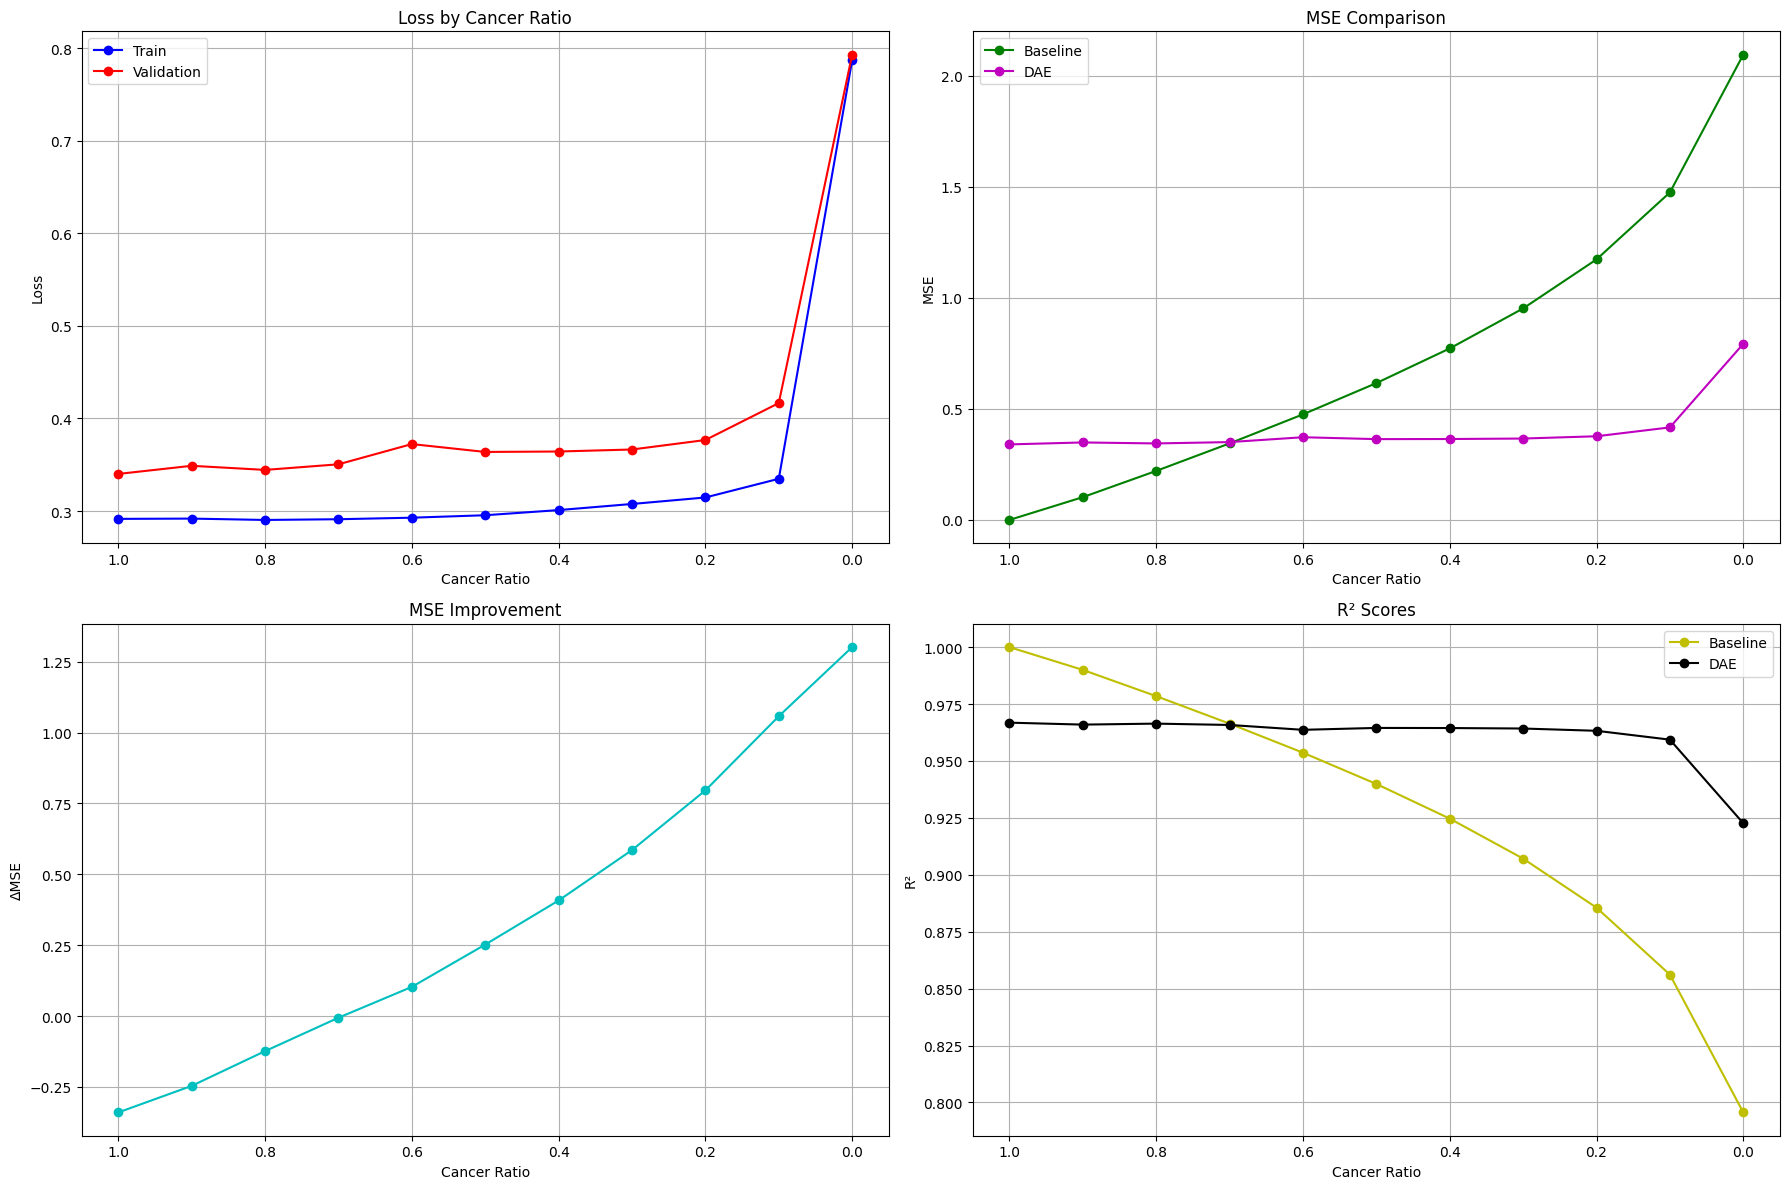

In [ ]:
def plot_results(results):
    # Sort results by cancer_ratio in descending order (1.0 to 0.0)
    results_sorted = sorted(results, key=lambda x: x['cancer_ratio'], reverse=True)
    ratios = [r['cancer_ratio'] for r in results_sorted]

    plt.figure(figsize=(18, 12))

    # Plot 1: Training and validation loss
    plt.subplot(2, 2, 1)
    plt.plot(ratios, [r['train_loss'] for r in results_sorted], 'b-o', label='Train')
    plt.plot(ratios, [r['val_loss'] for r in results_sorted], 'r-o', label='Validation')
    plt.xlabel('Cancer Ratio'); plt.ylabel('Loss'); plt.title('Loss by Cancer Ratio')
    plt.legend(); plt.grid(True)
    plt.gca().invert_xaxis()  # Reverse x-axis

    # Plot 2: MSE (Baseline vs. DAE)
    plt.subplot(2, 2, 2)
    plt.plot(ratios, [r['mse_noisy'] for r in results_sorted], 'g-o', label='Baseline')
    plt.plot(ratios, [r['mse_dae'] for r in results_sorted], 'm-o', label='DAE')
    plt.xlabel('Cancer Ratio'); plt.ylabel('MSE'); plt.title('MSE Comparison')
    plt.legend(); plt.grid(True)
    plt.gca().invert_xaxis()

    # Plot 3: ΔMSE (Improvement by DAE)
    plt.subplot(2, 2, 3)
    plt.plot(ratios, [r['mse_improvement'] for r in results_sorted], 'c-o')
    plt.xlabel('Cancer Ratio'); plt.ylabel('ΔMSE'); plt.title('MSE Improvement')
    plt.grid(True)
    plt.gca().invert_xaxis()

    # Plot 4: R² Scores (Baseline vs. DAE)
    plt.subplot(2, 2, 4)
    plt.plot(ratios, [r['r2_noisy'] for r in results_sorted], 'y-o', label='Baseline')
    plt.plot(ratios, [r['r2_dae'] for r in results_sorted], 'k-o', label='DAE')
    plt.xlabel('Cancer Ratio'); plt.ylabel('R²'); plt.title('R² Scores')
    plt.legend(); plt.grid(True)
    plt.gca().invert_xaxis()

    plt.tight_layout()
    plt.show()

plot_results(results)

In [ ]:
# Print final summary table of results (train/val loss, MSE, R², and ΔMSE for each cancer ratio)
print("\nFinal Results:")
print("Cancer\tTrain\tVal\tBaseline\tDAE\t\tImprovement")
print("Ratio\tLoss\tLoss\tMSE\tR²\tMSE\tR²\tΔMSE")
for r in results:
    print(f"{r['cancer_ratio']:.1f}\t{r['train_loss']:.4f}\t{r['val_loss']:.4f}\t"
          f"{r['mse_noisy']:.4f}\t{r['r2_noisy']:.4f}\t"
          f"{r['mse_dae']:.4f}\t{r['r2_dae']:.4f}\t"
          f"{r['mse_improvement']:.4f}")


Final Results:
Cancer	Train	Val	Baseline	DAE		Improvement
Ratio	Loss	Loss	MSE	R²	MSE	R²	ΔMSE
1.0	0.2915	0.3401	0.0000	1.0000	0.3401	0.9668	-0.3401
0.9	0.2918	0.3488	0.1025	0.9900	0.3489	0.9660	-0.2464
0.8	0.2904	0.3444	0.2206	0.9785	0.3444	0.9664	-0.1238
0.7	0.2911	0.3505	0.3445	0.9664	0.3505	0.9658	-0.0060
0.6	0.2928	0.3723	0.4752	0.9536	0.3723	0.9637	0.1029
0.5	0.2955	0.3638	0.6159	0.9399	0.3638	0.9645	0.2521
0.4	0.3010	0.3643	0.7720	0.9247	0.3643	0.9645	0.4077
0.3	0.3076	0.3665	0.9520	0.9071	0.3665	0.9642	0.5856
0.2	0.3146	0.3767	1.1727	0.8856	0.3767	0.9632	0.7960
0.1	0.3348	0.4166	1.4743	0.8561	0.4166	0.9593	1.0577
0.0	0.7870	0.7930	2.0946	0.7956	0.7930	0.9226	1.3016


In [ ]:
# Prepare test data (pure cancer)
X_test = torch.FloatTensor(np.log2(test_data + 0.1).T.values)
y_test = torch.FloatTensor(np.log2(test_data + 0.1).T.values)  # Target is same as input for pure cancer

# Create test dataset and loader
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=200, shuffle=False)

In [ ]:
# Function to evaluate on test data
def evaluate_test_corrected(model, test_loader, device):
    model.eval()
    criterion = nn.MSELoss()
    test_loss = 0
    all_outputs = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            test_loss += criterion(outputs, batch_y).item()

            # Store for metrics calculation
            all_outputs.append(outputs.cpu().numpy())
            all_targets.append(batch_y.cpu().numpy())

    test_loss /= len(test_loader)

    # Concatenate all batches
    all_outputs = np.concatenate(all_outputs, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    # Calculate metrics - compare DAE output to target
    mse_dae = mean_squared_error(all_targets.reshape(-1), all_outputs.reshape(-1))
    r2_dae = r2_score(all_targets.reshape(-1), all_outputs.reshape(-1))

    return {
        'test_loss': test_loss,
        'mse_dae': mse_dae,
        'r2_dae': r2_dae
    }

# Evaluate each trained model on test data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\n" + "="*60)
print("CORRECTED TEST DATA EVALUATION - Pure Cancer Samples")
print("="*60)
print("Trained on\tTest Loss\tDAE MSE\t\tDAE R²")
print("-"*55)

test_results = []
for cancer_ratio in ratios_to_test:
    try:
        # Load the model
        model = DAE().to(device)
        model_filename = f'saved_models/model_ratio_{cancer_ratio:.1f}.pth'
        model.load_state_dict(torch.load(model_filename))
        model.eval()

        # Evaluate on test data
        test_metrics = evaluate_test_corrected(model, test_loader, device)

        # Store results
        test_results.append({
            'trained_ratio': cancer_ratio,
            **test_metrics
        })

        print(f"{cancer_ratio:.1f}\t\t{test_metrics['test_loss']:.6f}\t{test_metrics['mse_dae']:.6f}\t{test_metrics['r2_dae']:.6f}")

    except FileNotFoundError:
        print(f"Model for ratio {cancer_ratio:.1f} not found, skipping...")
    except Exception as e:
        print(f"Error loading model for ratio {cancer_ratio:.1f}: {e}")

# Save test results
test_results_df = pd.DataFrame(test_results)
test_results_df.to_csv('saved_models/test_results_pure_cancer_corrected.csv', index=False)
print("\nTest results saved to 'saved_models/test_results_pure_cancer_corrected.csv'")



CORRECTED TEST DATA EVALUATION - Pure Cancer Samples
Trained on	Test Loss	DAE MSE		DAE R²
-------------------------------------------------------
1.0		0.332002	0.338513	0.966958
0.9		0.411605	0.421349	0.958873
0.8		0.496088	0.512410	0.949985
0.7		0.709972	0.733457	0.928409
0.6		1.005352	1.041623	0.898329
0.5		1.295945	1.351162	0.868115
0.4		1.672012	1.754894	0.828708
0.3		2.449720	2.573308	0.748824
0.2		4.928194	5.193392	0.493082
0.1		11.096045	11.786699	-0.150479
0.0		0.782912	0.806159	0.921312

Test results saved to 'saved_models/test_results_pure_cancer_corrected.csv'


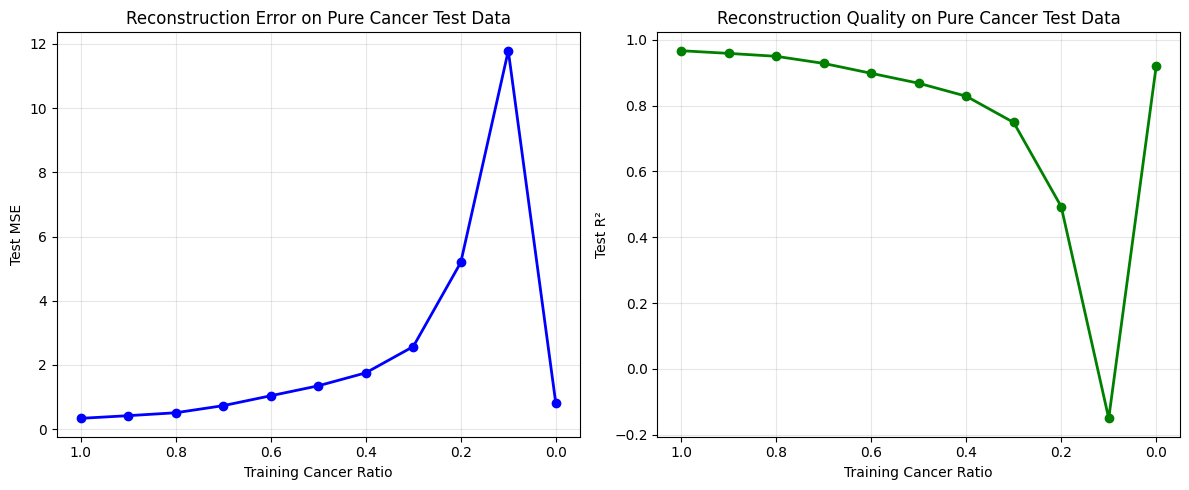

In [ ]:
# Visualization of Results
def plot_pure_test_results(test_results):
    if not test_results:
        print("No test results to plot")
        return

    # Sort by trained ratio
    test_results_sorted = sorted(test_results, key=lambda x: x['trained_ratio'], reverse=True)
    ratios = [r['trained_ratio'] for r in test_results_sorted]

    plt.figure(figsize=(12, 5))

    # Plot 1: Test MSE
    plt.subplot(1, 2, 1)
    plt.plot(ratios, [r['mse_dae'] for r in test_results_sorted], 'b-o', linewidth=2, markersize=6)
    plt.xlabel('Training Cancer Ratio')
    plt.ylabel('Test MSE')
    plt.title('Reconstruction Error on Pure Cancer Test Data')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_xaxis()

    # Plot 2: Test R²
    plt.subplot(1, 2, 2)
    plt.plot(ratios, [r['r2_dae'] for r in test_results_sorted], 'g-o', linewidth=2, markersize=6)
    plt.xlabel('Training Cancer Ratio')
    plt.ylabel('Test R²')
    plt.title('Reconstruction Quality on Pure Cancer Test Data')
    plt.grid(True, alpha=0.3)
    plt.gca().invert_xaxis()

    plt.tight_layout()
    plt.show()

# Plot the results
plot_pure_test_results(test_results)

In [ ]:
# Analysis
if test_results:
    # Find best performing model
    best_model_mse = min(test_results, key=lambda x: x['mse_dae'])
    best_model_r2 = max(test_results, key=lambda x: x['r2_dae'])

    print(f"\nBest model by MSE: Trained on {best_model_mse['trained_ratio']:.1f} cancer ratio")
    print(f"MSE: {best_model_mse['mse_dae']:.6f}, R²: {best_model_mse['r2_dae']:.6f}")

    print(f"\nBest model by R²: Trained on {best_model_r2['trained_ratio']:.1f} cancer ratio")
    print(f"MSE: {best_model_r2['mse_dae']:.6f}, R²: {best_model_r2['r2_dae']:.6f}")


Best model by MSE: Trained on 1.0 cancer ratio
MSE: 0.338513, R²: 0.966958

Best model by R²: Trained on 1.0 cancer ratio
MSE: 0.338513, R²: 0.966958
